In [1]:

import matplotlib.pyplot as plt
from seeg_tool import *

import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io 
import mne
import os
import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *


in_path = r"E:/workspace/study2_escape_task_seeg/seeg7_roi_data/hippo_v2/" # 分析哪个roi就输入哪个文件夹的数据

behavior_path = "E:/workspace/study2_escape_task_seeg/behavior/" # 分析哪个roi就输入哪个文件夹的数据

# subjects = [2, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,39,40,41,42,43] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

# subjects = [4, 5, 6, 8, 9, 11, 12, 14, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,39,40,41,42,43,45,46,47] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
subjects = [134, 135,137,138,148,150,151,154, 161, 162] # 所有好的被试

# subjects = [134, 135, 138, 150, 161, 162]  # vmpfc
# subjects = [134, 135, 137, 138, 148,161,162]  # amy
subjects = [134, 135,137,138,150,151,154,161,162] # hippo subjects = [134, 135,137,138,148,150,151,154] # hippo

# subjects = [134, 135, 138,150,151,154,161,162] # insula    [134, 135, 138, 148, 150,151,154] 

# subjects = [161,162] # mcc    [134, 135, 138, 148, 150,151,154] 

# subjects = [48] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少
len(subjects)
# 7
# subjects = [15] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少


9

In [57]:
hm_shutdown(1800)

In [2]:
#使用平均所有基线进行校正
from mne.time_frequency import tfr_morlet

freqs=np.arange(70, 120, 5)
n_cycles=10
# n_cycles=freqs/10


import numpy as np # 跨trial之后的平均
import copy
def apply_zlogratio_baseline(epochs_tfr, baseline):
    # 深度拷贝原始对象避免修改原数据
    new_tfr = copy.deepcopy(epochs_tfr)
    
    # 获取时间轴
    times = new_tfr.times
    
    # 确定基线时间段索引
    baseline_mask = np.logical_and(times >= baseline[0], times <= baseline[1])
    baseline_idx = np.where(baseline_mask)[0]
    
    if len(baseline_idx) == 0:
        raise ValueError("Baseline时间段内没有有效时间点")
    
    # 获取数据数组 (n_epochs, n_channels, n_freqs, n_times)
    data = new_tfr.data
    
    # 计算基线期间原始数据的均值（跨所有epoch和时间）
    baseline_data = data[:, :, :, baseline_idx]
    bl_mean = np.mean(baseline_data, axis=(0, 3))  # (n_channels, n_freqs)
    
    # 计算ratio并取log10
    ratio = data / bl_mean[np.newaxis, :, :, np.newaxis]
    log_ratio = np.log10(ratio)
    
    # 计算基线期间log ratio的标准差
    baseline_log = log_ratio[:, :, :, baseline_idx]
    bl_std = np.std(baseline_log, axis=(0, 3), ddof=1)  # (n_channels, n_freqs)
    
    # 应用z-score标准化
    zlog_data = log_ratio / bl_std[np.newaxis, :, :, np.newaxis]
    
    # 将处理后的数据存入新对象
    new_tfr.data = zlog_data
    
    # 添加基线信息（MNE对象的标准属性）
    new_tfr.baseline = baseline
    
    return new_tfr

freqs=np.arange(4, 31, 1) # 4 5 6 7     8 9 10 11 12 13
n_cycles = np.linspace(2, 5, num=27)
# freqs = freqs[0:4]  # theta
# n_cycles = n_cycles[0:4]
# # freqs = freqs[4:10]  # Alpha
# # n_cycles = n_cycles[4:10]
# freqs = freqs[10:]  # Beta
# n_cycles = n_cycles[10:]

# n_cycles =4
time_span = 100
ch_names = []
decision_time_range = [-1.0, 3] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s

# 生成时间序列
time_range = np.arange(baseline_range[0]-baseline_range[1] + decision_time_range[0], decision_time_range[1], 0.001)

all_sub_imminent_data = []
all_sub_moderate_data = []
imminent_trial_num, moderate_trial_num = 0, 0
for i in range(len(subjects)):

    # 导入数据 删除眼电 设置电极位置
    ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')
    # EEG_epochs = mne.read_epochs_eeglab(epoch_path + 'sub' + str(subjects[i]) + '_2_1.set')

    ROI_epochs.crop(-1.1, 16)
    # 降采样

    # 导入行为数据
    # hebavior_trial = pd.read_csv(behavior_path + str(subjects[i]) + '/subject_v2.csv')
    hebavior_trial = pd.read_excel(behavior_path + str(subjects[i]) + '/subject_v4.xlsx')

    print(len(hebavior_trial))

    # 提取不同条件是第几个试次
    # nothreat_event_num = np.squeeze(np.where(hebavior_trial['event_num']==11))
    # safe_imminent_event_num = np.squeeze(np.where(((hebavior_trial['event_num']==22) & (hebavior_trial['get_safe']==1)) & ~(hebavior_trial['firsttime_stage_3'].str.len()> 0)))
    # safe_moderate_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) & (hebavior_trial['get_safe']==1)) & (hebavior_trial['too_fast']==0)))
    safe_imminent_event_num = np.squeeze(np.where((hebavior_trial['event_num']==22) & ~(hebavior_trial['firsttime_stage_3'].str.len() > 0)))
    safe_moderate_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) ) & ~(hebavior_trial['firsttime_stage_3'].str.len()> 0)))

    imminent_trial_num +=  len(safe_imminent_event_num)
    moderate_trial_num += len(safe_moderate_event_num)
    # 统一计算tfr
    # tfr_epochs_nothreat = tfr_morlet(EEG_epochs[nothreat_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=4)
    ################################### 先分组后基线校正
    # tfr_epochs_safe_imminent = tfr_morlet(ROI_epochs[safe_imminent_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)
    # tfr_epochs_safe_moderate = tfr_morlet(ROI_epochs[safe_moderate_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)

    # tfr_epochs_safe_imminent = apply_zlogratio_baseline(tfr_epochs_safe_imminent, [-0.5, -0.1])
    # tfr_epochs_safe_imminent.apply_baseline(mode='mean', baseline=(-0.5, -0.1)) 
    # tfr_epochs_safe_moderate = apply_zlogratio_baseline(tfr_epochs_safe_moderate, [-0.5, -0.1])
    # tfr_epochs_safe_moderate.apply_baseline(mode='mean', baseline=(-0.5, -0.1)) 



    ########################################## 先基线校正后分组

    all_tfr = tfr_morlet(ROI_epochs, freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)
    # tfr_epochs_safe_moderate = tfr_morlet(ROI_epochs[safe_moderate_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)

    # 基线校正 对trial baseline的平均进行校正
    all_tfr = apply_zlogratio_baseline(all_tfr, [-0.5, -0.1])
    all_tfr.apply_baseline(mode='mean', baseline=(-0.5, -0.1)) 

    tfr_epochs_safe_imminent = all_tfr
    tfr_epochs_safe_moderate = all_tfr
    tfr_epochs_safe_imminent = all_tfr[safe_imminent_event_num]
    tfr_epochs_safe_moderate = all_tfr[safe_moderate_event_num]
    ###########################################
    # 截取baseline的信号作为基准  baseline_range
    # tfr_epochs_nothreat_baseline_data = tfr_epochs_nothreat.copy().crop(baseline_range[0], baseline_range[1]-0.004).data
    tfr_epochs_safe_imminent_baseline_data = tfr_epochs_safe_imminent.copy().crop(baseline_range[0], baseline_range[1]-0.001).data
    tfr_epochs_safe_moderate_baseline_data = tfr_epochs_safe_moderate.copy().crop(baseline_range[0], baseline_range[1]-0.001).data

    # # 分三个condition进行决策反应前后的截取，后续的对齐，然后进行生成新的mne tfr数据
    # for iter_trial in range(tfr_epochs_nothreat_baseline_data.shape[0]):

    #     # 结合每个trial的数据确定每个trial要截取的时间窗
    #     iter_trialtime = decision_time_range + np.array(hebavior_trial['firsttime_stage_3'])[nothreat_event_num[iter_trial]]

    #     # 利用mne的函数截取数据
    #     iter_tfr_epochs_nothreat = tfr_epochs_nothreat.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.004).data

    #     # 存储数据
    #     if iter_trial == 0: 
    #         iter_subject_nothreat_data = iter_tfr_epochs_nothreat
    #     else: 
    #         iter_subject_nothreat_data = np.vstack((iter_subject_nothreat_data, iter_tfr_epochs_nothreat))

    # 高威胁攻击
    discarded_trial_1 = []
    empty_or_not = 0
    for iter_trial in range(tfr_epochs_safe_imminent_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(float(hebavior_trial['firsttime_stage_3'][safe_imminent_event_num[iter_trial]]))
        if iter_trialtime[1] < 16 - 0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_imminent_data = tfr_epochs_safe_imminent.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.001).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_imminent_data = iter_safe_imminent_data
                empty_or_not = 1
            else: 
                iter_subject_safe_imminent_data = np.vstack((iter_subject_safe_imminent_data, iter_safe_imminent_data))
        else:
            discarded_trial_1.append(iter_trial)

    # 低威胁攻击
    discarded_trial_2 = []
    empty_or_not = 0
    for iter_trial in range(tfr_epochs_safe_moderate_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(float(hebavior_trial['firsttime_stage_3'][safe_moderate_event_num[iter_trial]]))
        if iter_trialtime[1] < 16-0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_moderate_data = tfr_epochs_safe_moderate.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.001).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_moderate_data = iter_safe_moderate_data
                empty_or_not = 1
            else: 
                iter_subject_safe_moderate_data = np.vstack((iter_subject_safe_moderate_data, iter_safe_moderate_data))
        else:
            discarded_trial_2.append(iter_trial)

    # 合并基线段和选择段的数据, slow情况下太长的数据删除
    # iter_subject_safe_imminent_data = np.concatenate((tfr_epochs_safe_imminent_baseline_data, iter_subject_safe_imminent_data), axis=3)
    iter_subject_safe_imminent_data = np.concatenate((np.delete(tfr_epochs_safe_imminent_baseline_data, discarded_trial_1, axis=0), iter_subject_safe_imminent_data), axis=3)

    iter_subject_safe_moderate_data = np.concatenate((np.delete(tfr_epochs_safe_moderate_baseline_data, discarded_trial_2, axis=0), iter_subject_safe_moderate_data), axis=3)

    # 生成mne的tfr文件准备进行基线校正
    info = mne.create_info(ch_names = ROI_epochs.ch_names, ch_types = 'eeg', sfreq = 1000)
    # 将所有trial进行平均
    all_imminent_mean_data = np.mean(iter_subject_safe_imminent_data, axis=0)
    all_moderate_mean_data = np.mean(iter_subject_safe_moderate_data, axis=0)
    # 生成mne的tfr文件
    all_imminent_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_imminent_mean_data, times=time_range, freqs=freqs, nave=1)
    all_moderate_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_moderate_mean_data, times=time_range, freqs=freqs, nave=1)

    # 基线校正
    # all_imminent_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.8, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1), verbose=False) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # all_moderate_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.8, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1), verbose=False) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_imminent_mean_tfr.apply_baseline(mode='mean', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_moderate_mean_tfr.apply_baseline(mode='mean', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio zscore
    # 高斯滤波
    # smooth_hgb_fast_data = np.mean(all_fast_mean_tfr.data,axis=1)
    # smooth_hgb_slow_data = np.mean(all_slow_mean_tfr.data,axis=1)
    smooth_hgb_imminent_data = gaussian_filter(data=np.mean(all_imminent_mean_tfr.data,axis=1), time_span=time_span, fs=ROI_epochs.info['sfreq'])
    smooth_hgb_moderate_data = gaussian_filter(data=np.mean(all_moderate_mean_tfr.data,axis=1), time_span=time_span, fs=ROI_epochs.info['sfreq'])
    # 得到的数据: trial, channel, time
  
    if i == 0:
        all_smooth_hgb_imminent_data = smooth_hgb_imminent_data
        all_smooth_hgb_moderate_data = smooth_hgb_moderate_data
        ch_names = np.array(ROI_epochs.ch_names)
    else:
        all_smooth_hgb_imminent_data = np.vstack((all_smooth_hgb_imminent_data, smooth_hgb_imminent_data))
        all_smooth_hgb_moderate_data = np.vstack((all_smooth_hgb_moderate_data, smooth_hgb_moderate_data))
        ch_names = np.hstack((ch_names, np.array(ROI_epochs.ch_names)))

    # print(smooth_hgb_slow_data.shape)

Extracting parameters from E:/workspace/study2_escape_task_seeg/seeg7_roi_data/amy_v2/134.set...
Not setting metadata
Not setting metadata
90 matching events found
No baseline correction applied
0 projection items activated
Ready.


<ipython-input-2-3f18df0927c1>:75: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')
<ipython-input-2-3f18df0927c1>:78: RuntimeWarning: tmax is not in epochs time interval. tmax is set to epochs.tmax
  ROI_epochs.crop(-1.1, 16)


90


[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    5.4s remaining:    5.4s


KeyboardInterrupt: 

In [9]:
#个体水平
from mne.time_frequency import tfr_morlet

freqs=np.arange(70, 120, 5)
n_cycles=10
time_span = 100

# n_cycles=freqs/10


freqs=np.arange(4, 31, 1) # 4 5 6 7     8 9 10 11 12 13
n_cycles = np.linspace(2, 5, num=27)
freqs = freqs[0:4]  # theta
n_cycles = n_cycles[0:4]
time_span = 3

# freqs = freqs[4:10]  # Alpha
# n_cycles = n_cycles[4:10]
# freqs = freqs[10:]  # Beta
# n_cycles = n_cycles[10:]

# n_cycles =4
ch_names = []
decision_time_range = [-1.0, 3] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s

# 生成时间序列
time_range = np.arange(baseline_range[0]-baseline_range[1] + decision_time_range[0], decision_time_range[1], 0.001)

all_sub_imminent_data = []
all_sub_moderate_data = []
imminent_trial_num, moderate_trial_num = 0, 0
for i in range(len(subjects)):

    # 导入数据 删除眼电 设置电极位置
    ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')
    # EEG_epochs = mne.read_epochs_eeglab(epoch_path + 'sub' + str(subjects[i]) + '_2_1.set')

    ROI_epochs.crop(-1.1, 16)
    # 降采样

    # 导入行为数据
    # hebavior_trial = pd.read_csv(behavior_path + str(subjects[i]) + '/subject_v2.csv')
    hebavior_trial = pd.read_excel(behavior_path + str(subjects[i]) + '/subject_v4.xlsx')

    # print(len(hebavior_trial))

    # 提取不同条件是第几个试次
    # nothreat_event_num = np.squeeze(np.where(hebavior_trial['event_num']==11))
    # safe_imminent_event_num = np.squeeze(np.where(((hebavior_trial['event_num']==22) & (hebavior_trial['get_safe']==1)) & ~(hebavior_trial['firsttime_stage_3'].str.len()> 0)))
    # safe_moderate_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) & (hebavior_trial['get_safe']==1)) & (hebavior_trial['too_fast']==0)))
    safe_imminent_event_num = np.squeeze(np.where((hebavior_trial['event_num']==22) & ~(hebavior_trial['firsttime_stage_3'].str.len() > 0)))
    safe_moderate_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) ) & ~(hebavior_trial['firsttime_stage_3'].str.len()> 0)))

    imminent_trial_num +=  len(safe_imminent_event_num)
    moderate_trial_num += len(safe_moderate_event_num)
    # 统一计算tfr
    # tfr_epochs_nothreat = tfr_morlet(EEG_epochs[nothreat_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=4)
    tfr_epochs_safe_imminent = tfr_morlet(ROI_epochs[safe_imminent_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)
    tfr_epochs_safe_moderate = tfr_morlet(ROI_epochs[safe_moderate_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)

    # 截取baseline的信号作为基准  baseline_range
    # tfr_epochs_nothreat_baseline_data = tfr_epochs_nothreat.copy().crop(baseline_range[0], baseline_range[1]-0.004).data
    tfr_epochs_safe_imminent_baseline_data = tfr_epochs_safe_imminent.copy().crop(baseline_range[0], baseline_range[1]-0.001).data
    tfr_epochs_safe_moderate_baseline_data = tfr_epochs_safe_moderate.copy().crop(baseline_range[0], baseline_range[1]-0.001).data

    # # 分三个condition进行决策反应前后的截取，后续的对齐，然后进行生成新的mne tfr数据
    # for iter_trial in range(tfr_epochs_nothreat_baseline_data.shape[0]):

    #     # 结合每个trial的数据确定每个trial要截取的时间窗
    #     iter_trialtime = decision_time_range + np.array(hebavior_trial['firsttime_stage_3'])[nothreat_event_num[iter_trial]]

    #     # 利用mne的函数截取数据
    #     iter_tfr_epochs_nothreat = tfr_epochs_nothreat.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.004).data

    #     # 存储数据
    #     if iter_trial == 0: 
    #         iter_subject_nothreat_data = iter_tfr_epochs_nothreat
    #     else: 
    #         iter_subject_nothreat_data = np.vstack((iter_subject_nothreat_data, iter_tfr_epochs_nothreat))

    # 高威胁攻击
    discarded_trial_1 = []
    empty_or_not = 0
    for iter_trial in range(tfr_epochs_safe_imminent_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(float(hebavior_trial['firsttime_stage_3'][safe_imminent_event_num[iter_trial]]))
        if iter_trialtime[1] < 16 - 0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_imminent_data = tfr_epochs_safe_imminent.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.001).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_imminent_data = iter_safe_imminent_data
                empty_or_not = 1
            else: 
                iter_subject_safe_imminent_data = np.vstack((iter_subject_safe_imminent_data, iter_safe_imminent_data))
        else:
            discarded_trial_1.append(iter_trial)

    # 低威胁攻击
    discarded_trial_2 = []
    empty_or_not = 0
    for iter_trial in range(tfr_epochs_safe_moderate_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(float(hebavior_trial['firsttime_stage_3'][safe_moderate_event_num[iter_trial]]))
        if iter_trialtime[1] < 16-0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_moderate_data = tfr_epochs_safe_moderate.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.001).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_moderate_data = iter_safe_moderate_data
                empty_or_not = 1
            else: 
                iter_subject_safe_moderate_data = np.vstack((iter_subject_safe_moderate_data, iter_safe_moderate_data))
        else:
            discarded_trial_2.append(iter_trial)

    # 合并基线段和选择段的数据, slow情况下太长的数据删除
    # iter_subject_safe_imminent_data = np.concatenate((tfr_epochs_safe_imminent_baseline_data, iter_subject_safe_imminent_data), axis=3)
    iter_subject_safe_imminent_data = np.concatenate((np.delete(tfr_epochs_safe_imminent_baseline_data, discarded_trial_1, axis=0), iter_subject_safe_imminent_data), axis=3)

    iter_subject_safe_moderate_data = np.concatenate((np.delete(tfr_epochs_safe_moderate_baseline_data, discarded_trial_2, axis=0), iter_subject_safe_moderate_data), axis=3)

    # 生成mne的tfr文件准备进行基线校正
    info = mne.create_info(ch_names = ROI_epochs.ch_names, ch_types = 'eeg', sfreq = 1000)
    # 将所有trial进行平均
    all_imminent_mean_data = np.mean(iter_subject_safe_imminent_data, axis=0)
    all_moderate_mean_data = np.mean(iter_subject_safe_moderate_data, axis=0)
    # 生成mne的tfr文件
    all_imminent_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_imminent_mean_data, times=time_range, freqs=freqs, nave=1)
    all_moderate_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_moderate_mean_data, times=time_range, freqs=freqs, nave=1)

    # 基线校正
    # all_imminent_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.8, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.05), verbose=False) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # all_moderate_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.8, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.05), verbose=False) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_imminent_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_moderate_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio zscore
    # 高斯滤波
    # smooth_hgb_fast_data = np.mean(all_fast_mean_tfr.data,axis=1)
    # smooth_hgb_slow_data = np.mean(all_slow_mean_tfr.data,axis=1)
    smooth_hgb_imminent_data = gaussian_filter(data=np.mean(all_imminent_mean_tfr.data,axis=1), time_span=time_span, fs=ROI_epochs.info['sfreq'])
    smooth_hgb_moderate_data = gaussian_filter(data=np.mean(all_moderate_mean_tfr.data,axis=1), time_span=time_span, fs=ROI_epochs.info['sfreq'])
    # 得到的数据: trial, channel, time
  
    if i == 0:
        all_smooth_hgb_imminent_data = smooth_hgb_imminent_data
        all_smooth_hgb_moderate_data = smooth_hgb_moderate_data
        ch_names = np.array(ROI_epochs.ch_names)
    else:
        all_smooth_hgb_imminent_data = np.vstack((all_smooth_hgb_imminent_data, smooth_hgb_imminent_data))
        all_smooth_hgb_moderate_data = np.vstack((all_smooth_hgb_moderate_data, smooth_hgb_moderate_data))
        ch_names = np.hstack((ch_names, np.array(ROI_epochs.ch_names)))

    print(smooth_hgb_imminent_data.shape)

Extracting parameters from E:/workspace/study2_escape_task_seeg/seeg7_roi_data/hippo_v2/134.set...
Not setting metadata
Not setting metadata
90 matching events found
No baseline correction applied
0 projection items activated
Ready.


<ipython-input-9-47162aeb2cd6>:36: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')
<ipython-input-9-47162aeb2cd6>:39: RuntimeWarning: tmax is not in epochs time interval. tmax is set to epochs.tmax
  ROI_epochs.crop(-1.1, 16)
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Not setting metadata


[Parallel(n_jobs=6)]: Done   2 out of   2 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=6)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Not setting metadata


...

[Parallel(n_jobs=6)]: Done   6 out of   9 | elapsed:    0.4s remaining:    0.1s
[Parallel(n_jobs=6)]: Done   9 out of   9 | elapsed:    0.5s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Not setting metadata


[Parallel(n_jobs=6)]: Done   6 out of   9 | elapsed:    0.3s remaining:    0.1s
[Parallel(n_jobs=6)]: Done   9 out of   9 | elapsed:    0.4s finished


Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)
(9, 6100)


d:\ProgramData\Anaconda3\envs\data_process\lib\site-packages\scipy\signal\windows\windows.py:1274: RuntimeWarning: divide by zero encountered in true_divide
  w = np.exp(-n ** 2 / sig2)
d:\ProgramData\Anaconda3\envs\data_process\lib\site-packages\scipy\signal\windows\windows.py:1274: RuntimeWarning: invalid value encountered in true_divide
  w = np.exp(-n ** 2 / sig2)


In [10]:
safe_imminent_event_num[iter_trial]

83

In [11]:
all_smooth_hgb_moderate_data.shape

(50, 6100)

In [19]:
print(imminent_trial_num)
print(moderate_trial_num)

267
268


In [12]:
# create a new epochs info
info_fast = mne.create_info(ch_names = list(np.arange(all_smooth_hgb_imminent_data.shape[0]).astype('str')), ch_types = 'eeg', sfreq = 1000)
info_slow = mne.create_info(ch_names = list(np.arange(all_smooth_hgb_moderate_data.shape[0]).astype('str')), ch_types = 'eeg', sfreq = 1000)

# create a new ROI based epochs
all_smooth_hgb_fast = mne.EvokedArray(data = all_smooth_hgb_imminent_data, info = info_fast, tmin=baseline_range[0]-baseline_range[1]+decision_time_range[0])
all_smooth_hgb_slow = mne.EvokedArray(data = all_smooth_hgb_moderate_data, info = info_slow, tmin=baseline_range[0]-baseline_range[1]+decision_time_range[0])
# all_smooth_hgb_fast.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.8, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1)) # 0.6 1
# all_smooth_hgb_slow.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.8, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1))

times = all_smooth_hgb_slow.times

all_smooth_hgb_fast_crop = all_smooth_hgb_fast.copy()
all_smooth_hgb_slow_crop = all_smooth_hgb_slow.copy()

all_smooth_hgb_fast_crop = all_smooth_hgb_fast_crop.crop(-0.5, 1.)
all_smooth_hgb_slow_crop = all_smooth_hgb_slow_crop.crop(-0.5, 1.) # vmpfc(0, 1.1)

all_smooth_hgb_fast_crop.apply_baseline(baseline = (-0.5,-0.0))
all_smooth_hgb_slow_crop.apply_baseline(baseline = (-0.5,-0.)) 

# all_smooth_hgb_fast_crop = all_smooth_hgb_fast_crop.crop(0.0, 1.)
# all_smooth_hgb_slow_crop = all_smooth_hgb_slow_crop.crop(0.0, 1.) # vmpfc(0, 1.1)
n_permutations = 10000

# 两种情况下相对于0的显著性
T_obs_fast, clusters_fast, cluster_p_values_fast, H0_fast  = mne.stats.permutation_cluster_1samp_test(all_smooth_hgb_fast_crop.data, 
                                                    out_type='mask',n_permutations=n_permutations, n_jobs=6, tail=0, verbose=None)

T_obs_slow, clusters_slow, cluster_p_values_slow, H0_slow  = mne.stats.permutation_cluster_1samp_test(all_smooth_hgb_slow_crop.data, 
                                                    out_type='mask',n_permutations=n_permutations, n_jobs=6, tail=0, verbose=None)

# anova
# 两者之间的显著性
# T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],
#                                                                 out_type='mask', n_permutations=n_permutations, n_jobs=6,tail=0
#                                                                 ,verbose=None, t_power=0) #, stat_fun=scipy.stats.ttest_ind())

# all_smooth_hgb_fast = all_smooth_hgb_fast.crop(-0.1, 1.1)
# all_smooth_hgb_slow = all_smooth_hgb_slow.crop(-0.1, 1.1)

# paired_ttest
def stat_fun_ttest_rel(X,Y):
    return scipy.stats.ttest_rel(X,Y).statistic
from scipy.stats import t
degrees_of_freedom = all_smooth_hgb_slow_crop.data.shape[0]-1
t_value_threshold = t.ppf(1 - 0.025, degrees_of_freedom)
print(t_value_threshold)
# 两者之间的显著性
T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],
                                                                out_type='mask', n_permutations=n_permutations, n_jobs=4,tail=0
                                                                ,verbose=None, t_power=1, threshold=t_value_threshold, stat_fun=stat_fun_ttest_rel)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Using a threshold of 2.009575
stat_fun(H1): min=nan max=nan
Running initial clustering
Found 0 clusters


<ipython-input-12-396436639f7b>:27: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs_fast, clusters_fast, cluster_p_values_fast, H0_fast  = mne.stats.permutation_cluster_1samp_test(all_smooth_hgb_fast_crop.data,


Using a threshold of 2.009575
stat_fun(H1): min=nan max=nan
Running initial clustering
Found 0 clusters


<ipython-input-12-396436639f7b>:27: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs_fast, clusters_fast, cluster_p_values_fast, H0_fast  = mne.stats.permutation_cluster_1samp_test(all_smooth_hgb_fast_crop.data,
<ipython-input-12-396436639f7b>:30: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs_slow, clusters_slow, cluster_p_values_slow, H0_slow  = mne.stats.permutation_cluster_1samp_test(all_smooth_hgb_slow_crop.data,


2.009575234489209
stat_fun(H1): min=nan max=nan
Running initial clustering
Found 0 clusters


<ipython-input-12-396436639f7b>:30: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs_slow, clusters_slow, cluster_p_values_slow, H0_slow  = mne.stats.permutation_cluster_1samp_test(all_smooth_hgb_slow_crop.data,
<ipython-input-12-396436639f7b>:50: RuntimeWarning: Provided stat_fun does not treat variables independently. Setting buffer_size to None.
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],
<ipython-input-12-396436639f7b>:50: RuntimeWarning: No clusters found, returning empty H0, clusters, and cluster_pv
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],


(array([-0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

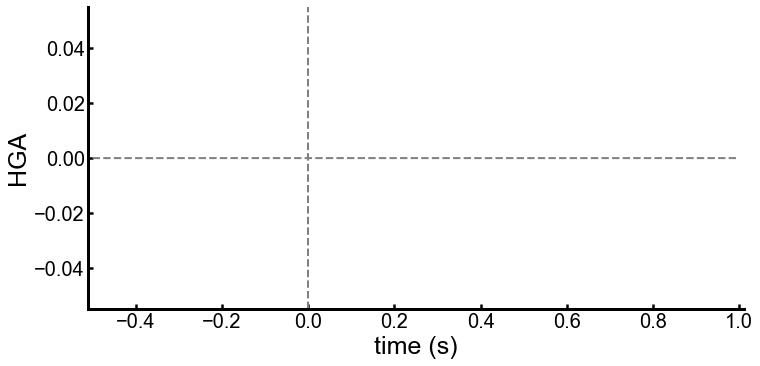

In [13]:
line_color = ['#E36A65','#5CBBBF']
# line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6

figsize=(13,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

# if not os.path.exists(result_path):
# os.mkdir(result_path)    
# # plot for each ROI
# for ROI_num in range(len(permutation_cluster_result['ROI_name'])):

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]

# the number of time axis
times = all_smooth_hgb_fast_crop.times

plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(all_smooth_hgb_fast_crop.data, axis=0))
epoch_mean[1] = np.squeeze(np.average(all_smooth_hgb_slow_crop.data, axis=0))

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')

# 标注哪条线是哪个event
#legend_font = {'family': fontproperties}
# plt.legend(['Fast Escaped', 'Slow Escaped'], fontsize=legend_size, frameon=False, loc='upper right') #, loc='top')

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
plt.axvline(times[500], c="gray", ls = "dashed", linewidth=2)
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--", linewidth=2)

# 画误差(std)
std_event0 = np.squeeze(np.std(all_smooth_hgb_fast_crop.data, axis=0))
std_event1 = np.squeeze(np.std(all_smooth_hgb_slow_crop.data, axis=0))

se_event0 = std_event0/np.sqrt(all_smooth_hgb_fast_crop.data.shape[0])
se_event1 = std_event1/np.sqrt(all_smooth_hgb_slow_crop.data.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
for i_c, c in enumerate(clusters_fast):
    c = c[0]
    if cluster_p_values_fast[i_c] <= 0.01666666:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
for i_c, c in enumerate(clusters_slow):
    c = c[0]
    if cluster_p_values_slow[i_c] <= 0.01666666:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# event 间的显著性
for i_c, c in enumerate(clusters):
    c = c[0]
    if cluster_p_values[i_c] <= 0.01666666:
        
        plt.plot(times[c.start : c.stop - 1], min_value-0.005 * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)


#hf = plt.plot(times, T_obs, 'g')
#plt.legend((h, ), ('cluster p-value < 0.05', ))
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.01, times[-1]+0.01])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("HGA", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_bipolar\decision_hpc.jpg',dpi=300, overwrite=True)
# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

In [10]:
print('fast')
print(clusters_fast, cluster_p_values_fast)
print('slow')
print(clusters_slow, cluster_p_values_slow)
print('compare')
print(clusters, cluster_p_values)

fast
[(slice(476, 938, None),), (slice(1074, 1149, None),)] [0.0011 0.2979]
slow
[(slice(330, 381, None),), (slice(1179, 1501, None),)] [0.3689 0.0217]
compare
[(slice(470, 824, None),), (slice(875, 949, None),)] [0.0011 0.2751]


In [19]:
# 读取前验证文件
from mne.io import read_raw_eeglab
raw = read_raw_eeglab('E:/workspace/study2_escape_task_seeg/seeg7_roi_data/amy/159.set', preload=False)
print(raw.info)

TypeError: The number of trials is 68. It must be 1 for raw files. Please use `mne.io.read_epochs_eeglab` if the .set file contains epochs.

In [4]:
# ROI_epochs = mne.read_epochs_eeglab('E:/workspace/study2_escape_task_seeg/seeg6_add_event_epoch//159.set')
ROI_epochs = mne.read_epochs_eeglab('E:/workspace/study2_escape_task_seeg/seeg7_roi_data/insula/159.set')


IndexError: list index out of range

In [2]:
safe_imminent_event_num

array(2, dtype=int64)

Extracting parameters from E:/workspace/study2_escape_task_seeg/seeg7_roi_data/vmpfc_v3/161.set...


<ipython-input-8-7134305847ae>:59: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')


Not setting metadata
Not setting metadata
90 matching events found
No baseline correction applied
0 projection items activated
Ready.


<ipython-input-8-7134305847ae>:62: RuntimeWarning: tmax is not in epochs time interval. tmax is set to epochs.tmax
  ROI_epochs.crop(-1.1, 16)


90


...


<ipython-input-8-7134305847ae>:208: RuntimeWarning: Ignoring argument "tail", performing 1-tailed F-test
  T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],


stat_fun(H1): min=0.000000 max=7.475091
Running initial clustering
Found 6 clusters
Permuting 9999 times...


100%|██████████|  : 9999/9999 [00:02<00:00, 4322.96it/s]


Computing cluster p-values
Done.


<ipython-input-8-7134305847ae>:333: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "overwrite" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(output_path + all_smooth_hgb_fast.ch_names[iter_channel] +  '.jpg' ,dpi=300, overwrite=True)
<ipython-input-8-7134305847ae>:333: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "overwrite" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(output_path + all_smooth_hgb_fast.ch_names[iter_channel] +  '.jpg' ,dpi=300, overwrite=True)
<ipython-input-8-7134305847ae>:333: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "overwrite" which is no longer supported as of 3.3 and will become an error two minor releases later
  plt.savefig(output_path + all_smooth_hgb_fast.ch_names[iter_channel] +  '.jpg' ,dpi=300, overwrite=True)
<ipython-input-8-7134305847ae>:333: MatplotlibDeprec

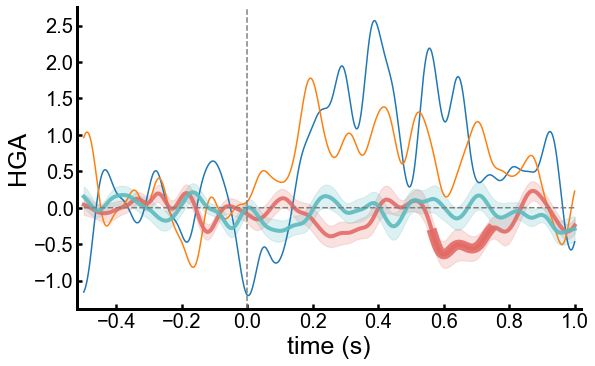

In [8]:
## 单独看每个被试的数据

from seeg_tool import *
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io 
import mne
import os
import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/')
from hm_tools import *

behavior_path = r"E:/workspace/study2_escape_task_seeg/behavior/"

roi = 'vmpfc_v3/'
# in_path = r"E:/workspace/sEEG_slow_fast_attack/roi_data_true/" # 分析哪个roi就输入哪个文件夹的数据
# in_path = r"E:/workspace/sEEG_slow_fast_attack/roi_data_bipolar/" # 分析哪个roi就输入哪个文件夹的数据
in_path = r"E:/workspace/study2_escape_task_seeg/seeg7_roi_data/" # 分析哪个roi就输入哪个文件夹的数据

in_path = in_path + roi
# roi_name = "amy"
subjects = [134, 135,137,138,148,150,151,154] # 所有好的被试

# subjects = [134, 135, 138, 150]  # vmpfc
# subjects = [134, 135, 137, 138, 148]  # amy
subjects = [134, 135,137,138,148,150,151,154] # hippo
# subjects = [134, 135, 138,148,150,151,154] # insula
#epochs_name = '/biomo_epo.fif'

subjects = [161,162]

from mne.time_frequency import tfr_morlet
# 快攻击成功是 '1/5/6'
# 快攻击失败是 '2/5/7/8'
# 慢攻击成功是 '3/5/6'
# 慢攻击过快时 '10/5/6'
# 慢攻击被捕捉是 '4/5/7/8'
# {'1/5/6': 1, '10/5/6': 2, '3/5/6': 3, '2/5/7/8': 4, '4/5/7/8': 5}
freqs=np.arange(70, 120, 5)
n_cycles=10
time_span = 100

# n_cycles =4
ch_names = []
decision_time_range = [-1.0, 5] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s

# 生成时间序列
time_range = np.arange(baseline_range[0]-baseline_range[1] + decision_time_range[0], decision_time_range[1], 0.001)

all_sub_imminent_data = []
all_sub_moderate_data = []
imminent_trial_num, moderate_trial_num = 0, 0
for i in range(len(subjects)):

    # 导入数据 删除眼电 设置电极位置
    ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')
    # EEG_epochs = mne.read_epochs_eeglab(epoch_path + 'sub' + str(subjects[i]) + '_2_1.set')

    ROI_epochs.crop(-1.1, 16)
    # 降采样

    # 导入行为数据
    # hebavior_trial = pd.read_csv(behavior_path + str(subjects[i]) + '/subject_v2.csv')
    hebavior_trial = pd.read_excel(behavior_path + str(subjects[i]) + '/subject_v4.xlsx')

    print(len(hebavior_trial))

    # 提取不同条件是第几个试次
    # nothreat_event_num = np.squeeze(np.where(hebavior_trial['event_num']==11))
    # safe_imminent_event_num = np.squeeze(np.where((hebavior_trial['event_num']==22) & (hebavior_trial['get_safe']==1)))
    # safe_moderate_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) & (hebavior_trial['get_safe']==1)) & (hebavior_trial['too_fast']==0)))
    safe_imminent_event_num = np.squeeze(np.where((hebavior_trial['event_num']==22) & ~(hebavior_trial['firsttime_stage_3'].str.len() > 0)))
    safe_moderate_event_num = np.squeeze(np.where(( ((hebavior_trial['event_num']==32) | (hebavior_trial['event_num']==31)) ) & ~(hebavior_trial['firsttime_stage_3'].str.len()> 0)))

    imminent_trial_num +=  len(safe_imminent_event_num)
    moderate_trial_num += len(safe_moderate_event_num)
    # 统一计算tfr
    # tfr_epochs_nothreat = tfr_morlet(EEG_epochs[nothreat_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=4)
    tfr_epochs_safe_imminent = tfr_morlet(ROI_epochs[safe_imminent_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)
    tfr_epochs_safe_moderate = tfr_morlet(ROI_epochs[safe_moderate_event_num], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=6)

    # 截取baseline的信号作为基准  baseline_range
    # tfr_epochs_nothreat_baseline_data = tfr_epochs_nothreat.copy().crop(baseline_range[0], baseline_range[1]-0.004).data
    tfr_epochs_safe_imminent_baseline_data = tfr_epochs_safe_imminent.copy().crop(baseline_range[0], baseline_range[1]-0.001).data
    tfr_epochs_safe_moderate_baseline_data = tfr_epochs_safe_moderate.copy().crop(baseline_range[0], baseline_range[1]-0.001).data

    # # 分三个condition进行决策反应前后的截取，后续的对齐，然后进行生成新的mne tfr数据
    # for iter_trial in range(tfr_epochs_nothreat_baseline_data.shape[0]):

    #     # 结合每个trial的数据确定每个trial要截取的时间窗
    #     iter_trialtime = decision_time_range + np.array(hebavior_trial['firsttime_stage_3'])[nothreat_event_num[iter_trial]]

    #     # 利用mne的函数截取数据
    #     iter_tfr_epochs_nothreat = tfr_epochs_nothreat.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.004).data

    #     # 存储数据
    #     if iter_trial == 0: 
    #         iter_subject_nothreat_data = iter_tfr_epochs_nothreat
    #     else: 
    #         iter_subject_nothreat_data = np.vstack((iter_subject_nothreat_data, iter_tfr_epochs_nothreat))

    # 高威胁攻击
    discarded_trial_1 = []
    empty_or_not = 0
    for iter_trial in range(tfr_epochs_safe_imminent_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(float(hebavior_trial['firsttime_stage_3'][safe_imminent_event_num[iter_trial]]))
        if iter_trialtime[1] < 16 - 0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_imminent_data = tfr_epochs_safe_imminent.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.001).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_imminent_data = iter_safe_imminent_data
                empty_or_not = 1
            else: 
                iter_subject_safe_imminent_data = np.vstack((iter_subject_safe_imminent_data, iter_safe_imminent_data))
        else:
            discarded_trial_1.append(iter_trial)

    # 低威胁攻击
    discarded_trial_2 = []
    empty_or_not = 0
    for iter_trial in range(tfr_epochs_safe_moderate_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(float(hebavior_trial['firsttime_stage_3'][safe_moderate_event_num[iter_trial]]))
        if iter_trialtime[1] < 16-0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_safe_moderate_data = tfr_epochs_safe_moderate.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.001).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_safe_moderate_data = iter_safe_moderate_data
                empty_or_not = 1
            else: 
                iter_subject_safe_moderate_data = np.vstack((iter_subject_safe_moderate_data, iter_safe_moderate_data))
        else:
            discarded_trial_2.append(iter_trial)

    # 合并基线段和选择段的数据, slow情况下太长的数据删除
    # iter_subject_safe_imminent_data = np.concatenate((tfr_epochs_safe_imminent_baseline_data, iter_subject_safe_imminent_data), axis=3)
    iter_subject_safe_imminent_data = np.concatenate((np.delete(tfr_epochs_safe_imminent_baseline_data, discarded_trial_1, axis=0), iter_subject_safe_imminent_data), axis=3)

    iter_subject_safe_moderate_data = np.concatenate((np.delete(tfr_epochs_safe_moderate_baseline_data, discarded_trial_2, axis=0), iter_subject_safe_moderate_data), axis=3)

    # 生成mne的tfr文件准备进行基线校正
    info = mne.create_info(ch_names = ROI_epochs.ch_names, ch_types = 'eeg', sfreq = 1000)
    # 将所有trial进行平均
    all_imminent_mean_data = np.mean(iter_subject_safe_imminent_data, axis=0)
    all_moderate_mean_data = np.mean(iter_subject_safe_moderate_data, axis=0)
    # 生成mne的tfr文件
    all_imminent_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_imminent_mean_data, times=time_range, freqs=freqs, nave=1)
    all_moderate_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_moderate_mean_data, times=time_range, freqs=freqs, nave=1)

    # 基线校正
    all_imminent_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.9, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.05), verbose=False) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_moderate_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.9, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.05), verbose=False) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # all_safe_imminent_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # all_safe_moderate_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio zscore
    # 高斯滤波
    # smooth_hgb_fast_data = np.mean(all_fast_mean_tfr.data,axis=1)
    # smooth_hgb_slow_data = np.mean(all_slow_mean_tfr.data,axis=1)
    smooth_hgb_imminent_data = gaussian_filter(data=np.mean(all_imminent_mean_tfr.data,axis=1), time_span=time_span, fs=ROI_epochs.info['sfreq'])
    smooth_hgb_moderate_data = gaussian_filter(data=np.mean(all_moderate_mean_tfr.data,axis=1), time_span=time_span, fs=ROI_epochs.info['sfreq'])
    # 得到的数据: trial, channel, time
  

    all_smooth_hgb_fast_data = smooth_hgb_imminent_data
    all_smooth_hgb_slow_data = smooth_hgb_moderate_data
    ch_names = np.array(ROI_epochs.ch_names)

    # create a new epochs info
    info = mne.create_info(ch_names = list(ch_names), ch_types = 'eeg', sfreq = 1000)

    # create a new ROI based epochs
    all_smooth_hgb_fast = mne.EvokedArray(data = all_smooth_hgb_fast_data, info = info, tmin=baseline_range[0]-baseline_range[1]+decision_time_range[0])
    all_smooth_hgb_slow = mne.EvokedArray(data = all_smooth_hgb_slow_data, info = info, tmin=baseline_range[0]-baseline_range[1]+decision_time_range[0])
    # all_smooth_hgb_fast.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.1, baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.2))
    # all_smooth_hgb_slow.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.1, baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.2))

    times = all_smooth_hgb_slow.times

    all_smooth_hgb_fast_crop = all_smooth_hgb_fast
    all_smooth_hgb_slow_crop = all_smooth_hgb_slow

    all_smooth_hgb_fast_crop = all_smooth_hgb_fast_crop.crop(-0.5, 1)
    all_smooth_hgb_slow_crop = all_smooth_hgb_slow_crop.crop(-0.5, 1) # vmpfc(0, 1.1)
    all_smooth_hgb_fast_crop.apply_baseline(baseline = (-0.5,-0.0))
    all_smooth_hgb_slow_crop.apply_baseline(baseline = (-0.5,-0.)) 

    n_permutations = 10000

    # 两种情况下相对于0的显著性
    T_obs_fast, clusters_fast, cluster_p_values_fast, H0_fast  = mne.stats.permutation_cluster_1samp_test(all_smooth_hgb_fast_crop.data, 
                                                        out_type='mask',n_permutations=n_permutations, n_jobs=6, tail=0, verbose=None)

    T_obs_slow, clusters_slow, cluster_p_values_slow, H0_slow  = mne.stats.permutation_cluster_1samp_test(all_smooth_hgb_slow_crop.data, 
                                                        out_type='mask',n_permutations=n_permutations, n_jobs=6, tail=0, verbose=None)

    # anova
    # 两者之间的显著性
    T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],
                                                                    out_type='mask', n_permutations=n_permutations, n_jobs=6,tail=0
                                                                    ,verbose=None) #, stat_fun=scipy.stats.ttest_ind())



    ##############################
    for iter_channel in range(all_smooth_hgb_slow_crop.data.shape[0]):
        line_color = ['#E36A65','#5CBBBF']    # 红色湖蓝色 正确快攻击，正确慢攻击 

        figsize=(10,6) 
        title_size=20
        legend_size=15

        ticksize=10
        subplots_adjust=[0.15, 0.15, 0.85, 0.85]


        import matplotlib.pyplot as plt
        import numpy as np
        import os

        event_0_line_color = line_color[0]
        event_1_line_color = line_color[1]

        # the number of time axis
        times = all_smooth_hgb_slow.times

        plt.close('all')
        plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
        # plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

        epoch_mean={}
        epoch_mean[0] = np.squeeze(np.average(all_smooth_hgb_fast.data, axis=0))
        epoch_mean[1] = np.squeeze(np.average(all_smooth_hgb_slow.data, axis=0))

        plt.plot(times, np.transpose(all_smooth_hgb_fast.data[iter_channel]))
        plt.plot(times, np.transpose(all_smooth_hgb_slow.data[iter_channel]))
        # plt.legend(['fast', 'slow'])

        plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
        plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')

        # 画每个电极的线：
        # tfr_ROI_epoch_fast.ch_names
        # plt.plot(times, np.transpose(all_smooth_hgb_fast.data))

        # 画0s时的分割线 
        plt.axvline(times[500], c="gray", ls = "dashed")
        plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

        # 画误差(std)
        std_event0 = np.squeeze(np.std(all_smooth_hgb_fast.data, axis=0))
        std_event1 = np.squeeze(np.std(all_smooth_hgb_slow.data, axis=0))

        se_event0 = std_event0/np.sqrt(all_smooth_hgb_fast.data.shape[0])
        se_event1 = std_event1/np.sqrt(all_smooth_hgb_fast.data.shape[0])

        plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
        plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)

        min_value_1 = np.min(epoch_mean[0] - se_event0)
        min_value_2 = np.min(epoch_mean[1] - se_event1)
        min_value = np.min([min_value_1, min_value_2])
        # event0 的显著性
        for i_c, c in enumerate(clusters_fast):
            c = c[0]
            if cluster_p_values_fast[i_c] <= 0.05:
                # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
                plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
        # event1 的显著性
        for i_c, c in enumerate(clusters_slow):
            c = c[0]
            if cluster_p_values_slow[i_c] <= 0.05:
                # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
                plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

        # event 间的显著性
        for i_c, c in enumerate(clusters):
            c = c[0]
            if cluster_p_values[i_c] <= 0.05:
                
                plt.plot(times[c.start : c.stop - 1], min_value-0.005 * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)

        #hf = plt.plot(times, T_obs, 'g')
        #plt.legend((h, ), ('cluster p-value < 0.05', ))
        plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

        plt.xlim([times[0]-0.02, times[-1]+0.02])

        plt.yticks(size=ticksize)
        plt.xticks(size=ticksize)

        spines_width = 3
        ax=plt.gca()
        ax.spines['top'].set_linewidth(0)
        ax.spines['right'].set_linewidth(0)
        ax.spines['left'].set_linewidth(spines_width)
        ax.spines['bottom'].set_linewidth(spines_width)
        # sns.despine()

        # 坐标轴刻度粗细,朝内
        plt.rcParams['xtick.major.size'] = 5
        plt.rcParams['ytick.major.size'] = 5
        plt.rcParams['xtick.major.width'] = 2.5
        plt.rcParams['ytick.major.width'] = 2.5
        plt.rcParams['xtick.direction'] = 'in'
        plt.rcParams['ytick.direction'] = 'in'
        # plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

        labelsize=25
        plt.xlabel("time (s)", fontsize=labelsize, fontproperties='Arial')
        plt.ylabel("HGA", size=labelsize, fontproperties='Arial')

        # 坐标的粗细
        ticksize = 20
        plt.yticks(size=ticksize, fontproperties='Arial')
        plt.xticks(size=ticksize, fontproperties='Arial')
        try:
            output_path = 'D:/Desktop/项目/escape_2d_seeg/画图/hga_each_subjects/'  
            output_path = output_path + roi + str(subjects[i]) + '/'
            os.makedirs(output_path)
        except:
            xxx=1

        plt.savefig(output_path + all_smooth_hgb_fast.ch_names[iter_channel] +  '.jpg' ,dpi=300, overwrite=True)
    # 蓝色是fast
    # plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

In [56]:
cluster_pv

array([1.   , 1.   , 0.989, 1.   , 1.   , 0.997, 0.997, 0.847, 0.998,
       0.989, 1.   , 0.001, 0.999, 0.993, 0.871, 0.999, 0.998, 1.   ,
       1.   ])

<ipython-input-26-09c11577c09b>:15: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  info.set_montage(mymontage)  # 使用 set_montage 方法附加通道布局


[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1]
(151, 63)


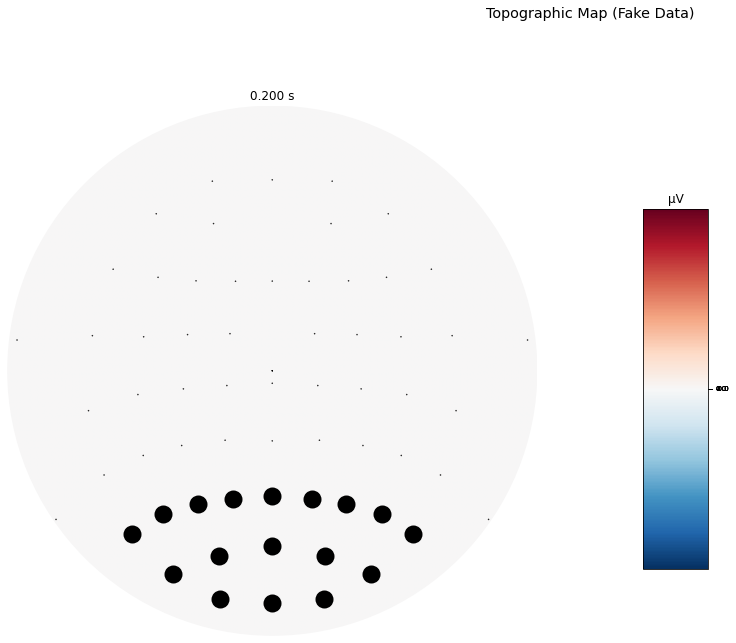

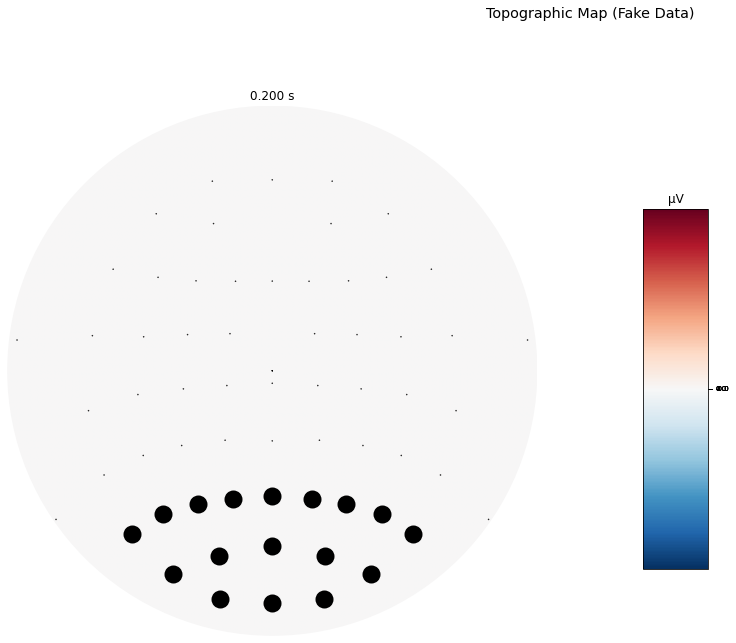

In [ ]:
# 画 三种roi的位置
import mne
import numpy as np
import matplotlib.pyplot as plt

# Step 1: 创建通道名称和通道位置
channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
n_channels = len(channel_names)

# 使用标准 10-20 系统的通道布局
# montage = mne.channels.make_standard_montage('standard_1020')

# Step 2: 创建假的信息结构
sfreq = 100  # 采样率 (Hz)
info = all_sub_moderate_epoch.info
info.set_montage(mymontage)  # 使用 set_montage 方法附加通道布局
all_channels = all_sub_imminent_epoch.ch_names
channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
channel_names = ['FC5', 'FC3', 'FC1', 'FC2', 'FC4','FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2','CP4', 'CP6']
channel_names = ['Pz', 'P1', 'P3', 'P5', 'P7', 'P2', 'P4', 'P6', 'P8','POz', 'PO3', 'PO7', 'PO4', 'PO8', 'Oz', 'O1', 'O2']

binary_sequence = [1 if ch in channel_names else 0 for ch in all_channels]
print(binary_sequence)
reshaped_sequence = np.tile(binary_sequence, (151, 1))
print(reshaped_sequence.shape)


# Step 3: 创建假的数据
n_times = 151  # 时间点数
times = np.linspace(0, 1.5, n_times)  # 时间范围 (0 到 1.5 秒)
fake_data = np.zeros((63, n_times))  # 全 0 的伪数据 (单位: 微伏)

# Step 4: 创建 Evoked 对象
evoked = mne.EvokedArray(fake_data, info, tmin=0)

# Step 5: 创建掩码
# 创建一个与数据形状匹配的掩码 (n_channels, n_times)
mask = np.zeros((63, n_times), dtype=bool)  # 初始化为全 False
mask[:, :50] = True  # 假设前 50 个时间点的所有通道都被标记

# Step 6: 绘制拓扑图
evoked.plot_topomap(
    mask=reshaped_sequence.T,  # 使用形状匹配的掩码
    mask_params=dict(marker='o', markersize=5, markerfacecolor='black'),
    times=[0.2],  # 指定时间点
    ch_type='eeg',
    title='Topographic Map (Fake Data)',
    size=6,
    outlines='head',
    cmap='RdBu_r',
)


-0.04280243074860559 -0.07483636769588455 (0.5716352409041623, 0.5710257137845899, True)


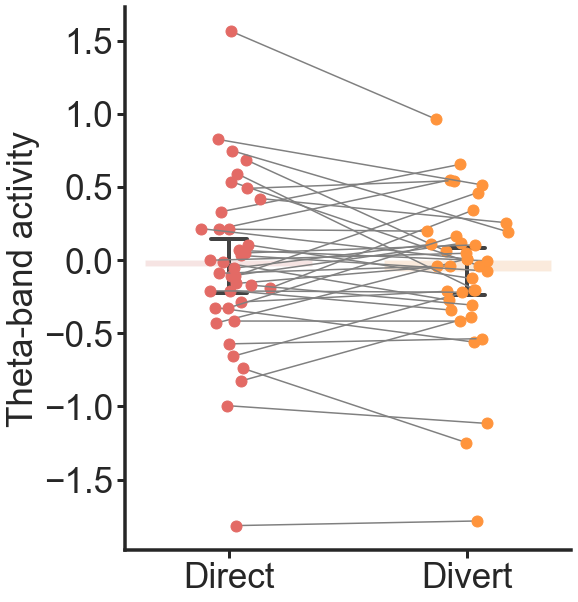

In [104]:
# 画所有被试的正确率 fast正确率，slow正确率，high_p_avg_get_reward

import sys
sys.path.insert(0, 'E:/workspace/my_py_toolbox/') 
from hm_tools import *
point_color = ['#E36A65', '#FF943C']
all_data_df = {}

# 正确率
all_data_df["Direct"] = np.array(list(each_sub_mean_data_imminent))
all_data_df["Divert"] = np.array(list(each_sub_mean_data_moderate))
print(np.mean(all_data_df['Direct']), np.mean(all_data_df['Divert']), hm_t_test_rel(all_data_df['Direct'],all_data_df['Divert']))

all_data_df = pd.DataFrame(all_data_df)

import seaborn as sns
import matplotlib.pyplot as plt

with sns.axes_style("ticks"):

    plt.rcParams['figure.figsize'] = (8,10) # 设置figure_size尺寸

    # sns.boxplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#deefe8", "#f9e3d9"])
    # ['#E36A65','#FF943C'] 
    sns.barplot(data=all_data_df, palette=point_color, width=0.7,capsize=0.15, errwidth=4, alpha=0.2)
    # sns.stripplot(data=all_data_df, x="group", y=FC, order = ["PL", "OT"], palette=["#66c2a5", "#fc8d62"], size=4)
    # sns.stripplot(data=all_data_df, palette=["#E36A65", "#5CBBBF", "#f9e3d9"], size=10)    # violinplot plot

    # 在横轴上略微打乱一下点 （替代stripplot）
    jitter = 0.07
    df_x_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=all_data_df.values.shape), columns=all_data_df.columns)
    df_x_jitter += np.arange(len(all_data_df.columns))

    for i in range(len(all_data_df)):
        plt.plot([df_x_jitter["Direct"][i], df_x_jitter["Divert"][i]], [all_data_df["Direct"][i], all_data_df["Divert"][i]], color="grey")
        plt.plot(df_x_jitter["Direct"][i], all_data_df["Direct"][i], marker="o", color=point_color[0], markersize=11)
        plt.plot(df_x_jitter["Divert"][i], all_data_df["Divert"][i], marker="o", color=point_color[1], markersize=11)

    spines_width = 3.5
    ax=plt.gca()
    ax.spines['left'].set_linewidth(spines_width)
    ax.spines['bottom'].set_linewidth(spines_width)
    sns.despine()
    ticksize = 35
    plt.ylabel("Theta-band activity", size=ticksize, fontproperties='Arial')

    ticksize = 35
    # 坐标的粗细
    plt.yticks(size=ticksize, fontproperties='Arial')
    plt.xticks(size=ticksize, fontproperties='Arial')

    # plt.ylim([0.8, 1.2])

    # 刻度的粗细
    plt.tick_params(axis='x', width=3, size=8)
    plt.tick_params(axis='y', width=3, size=8)
    # plt.tight_layout()
# plt.savefig(r'D:\Desktop\项目\seeg\画图\fc_new\vmpfc_amy\psi_amy_vmpfc.jpg',dpi=500, overwrite=True)


In [93]:
all_sub_moderate_epoch.get_data().shape[0]

1

In [29]:
all_sub_moderate_epoch_copy.get_data().shape

(7, 16, 201)

In [105]:
# paired_ttest
def stat_fun_ttest_ind(X,Y):
    return scipy.stats.ttest_rel(X,Y).statistic
from scipy.stats import t
degrees_of_freedom = all_sub_moderate_epoch.get_data().shape[0] - 1
t_value_threshold = t.ppf(1 - 0.025, degrees_of_freedom)
# print(t_value_threshold)
all_sub_moderate_epoch_copy = all_sub_moderate_epoch.copy()
all_sub_imminent_epoch_copy = all_sub_imminent_epoch.copy()
# all_sub_moderate_epoch_copy.crop(0, 1.2)
# all_sub_imminent_epoch_copy.crop(0, 1.2)

n_permutations = 10000
# 两种情况下相对于0的显著性
T_obs_fast, clusters_fast, cluster_p_values_fast, H0_fast  = mne.stats.permutation_cluster_1samp_test(np.mean(all_sub_moderate_epoch_copy.get_data(), axis=1), 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs_slow, clusters_slow, cluster_p_values_slow, H0_slow  = mne.stats.permutation_cluster_1samp_test(np.mean(all_sub_imminent_epoch_copy.get_data(), axis=1), 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([np.mean(all_sub_moderate_epoch_copy.get_data(), axis=1), np.mean(all_sub_imminent_epoch_copy.get_data(), axis=1)],
                                                                out_type='mask', n_permutations=n_permutations, n_jobs=4,tail=0
                                                                ,verbose=None, t_power=0
                                                                ,threshold=t_value_threshold, stat_fun=stat_fun_ttest_ind)
print('moderate')
print(clusters_fast, cluster_p_values_fast)
print('imminent')
print(clusters_slow, cluster_p_values_slow)
print('compare')
print(clusters, cluster_p_values)

Using a threshold of 2.026192
stat_fun(H1): min=-3.620579 max=4.767487
Running initial clustering
Found 3 clusters
Permuting 9999 times...


100%|██████████|  : 9999/9999 [00:01<00:00, 7316.30it/s]

Computing cluster p-values
Done.
Using a threshold of 2.026192
stat_fun(H1): min=-2.767762 max=4.679580
Running initial clustering
Found 4 clusters


Permuting 9999 times...


100%|██████████|  : 9999/9999 [00:00<00:00, 17548.98it/s]


Computing cluster p-values
Done.
stat_fun(H1): min=-2.723017 max=2.447161
Running initial clustering
Found 3 clusters
Permuting 9999 times...


100%|██████████|  : 9999/9999 [00:02<00:00, 4180.98it/s]


Computing cluster p-values
Done.
moderate
[(slice(69, 79, None),), (slice(147, 151, None),), (slice(96, 120, None),)] [0.0383 0.3496 0.0067]
imminent
[(slice(66, 84, None),), (slice(149, 151, None),), (slice(104, 106, None),), (slice(111, 128, None),)] [0.012  0.686  0.7311 0.0388]
compare
[(slice(123, 134, None),), (slice(67, 71, None),), (slice(82, 83, None),)] [0.0457 0.3735 0.8121]


(array([-0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

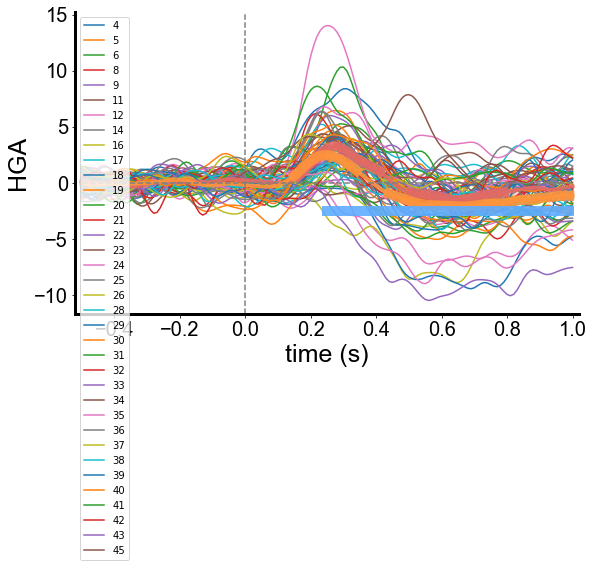

In [ ]:
# line_color = ['#E36A65','#5CBBBF']    # 红色湖蓝色 正确快攻击，正确慢攻击 
line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6
# line_color = ['#5CBBBF','#4482CD']    #  正确慢攻击，过快慢攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#4482CD']    #  错误快攻击，过快慢攻击  DE6B48  FFADC6

figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]

# the number of time axis
times = all_sub_moderate_epoch.times

data_1 = np.mean(all_sub_moderate_epoch.get_data(), axis=1)
data_2 = np.mean(all_sub_imminent_epoch.get_data(), axis=1)
plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(data_1, axis=0))
epoch_mean[1] = np.squeeze(np.average(data_2, axis=0))
plt.plot(times, np.transpose(data_1))
plt.plot(times, np.transpose(data_2))

# plt.plot(times, np.transpose(data_1[-2:]))


plt.legend(subjects)

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')

# 标注哪条线是哪个event
# legend_font = {'family': fontproperties}
# plt.legend(['Moderate', 'Imminent'], fontsize=legend_size, frameon=False)

# # 画每个电极的线：
# tfr_ROI_epoch_fast.ch_names

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
plt.axvline(times[20], c="gray", ls = "dashed")
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

# 画误差(std)
std_event0 = np.squeeze(np.std(data_1, axis=0))
std_event1 = np.squeeze(np.std(data_2, axis=0))

se_event0 = std_event0/np.sqrt(data_1.shape[0])
se_event1 = std_event1/np.sqrt(data_2.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
for i_c, c in enumerate(clusters_fast):
    c = c[0]
    if cluster_p_values_fast[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
for i_c, c in enumerate(clusters_slow):
    c = c[0]
    if cluster_p_values_slow[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# event 间的显著性
for i_c, c in enumerate(clusters):
    c = c[0]
    if cluster_p_values[i_c] <= 0.05:
        
        plt.plot(times[c.start : c.stop - 1], (min_value-0.005) * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)

#hf = plt.plot(times, T_obs, 'g')
#plt.legend((h, ), ('cluster p-value < 0.05', ))
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.02, times[-1]+0.02])
# plt.ylim([-3, 10])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("HGA", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_new_zlogratio\baseline_insula.jpg',dpi=300, overwrite=True)

# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

(array([-0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

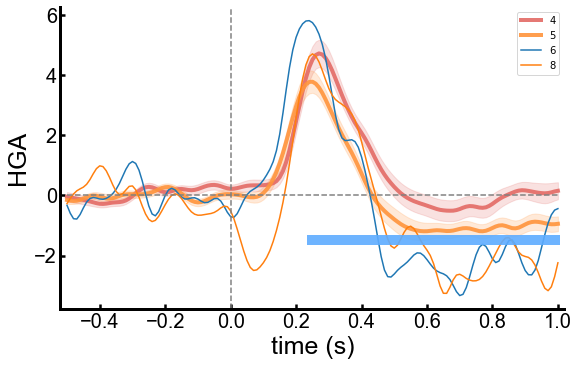

In [22]:
# line_color = ['#E36A65','#5CBBBF']    # 红色湖蓝色 正确快攻击，正确慢攻击 
line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6
# line_color = ['#5CBBBF','#4482CD']    #  正确慢攻击，过快慢攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#4482CD']    #  错误快攻击，过快慢攻击  DE6B48  FFADC6

figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]

# the number of time axis
times = all_sub_moderate_epoch.times

data_1 = np.mean(all_sub_moderate_epoch.get_data(), axis=1)
data_2 = np.mean(all_sub_imminent_epoch.get_data(), axis=1)
plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(data_1, axis=0))
epoch_mean[1] = np.squeeze(np.average(data_2, axis=0))

# plt.plot(times, np.transpose(data_2))

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, np.transpose(data_2[-2:]))
plt.legend(subjects)

# 标注哪条线是哪个event
# legend_font = {'family': fontproperties}
# plt.legend(['Moderate', 'Imminent'], fontsize=legend_size, frameon=False)

# # 画每个电极的线：
# tfr_ROI_epoch_fast.ch_names
# plt.plot(times, np.transpose(data_2))

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
plt.axvline(times[50], c="gray", ls = "dashed")
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

# 画误差(std)
std_event0 = np.squeeze(np.std(data_1, axis=0))
std_event1 = np.squeeze(np.std(data_2, axis=0))

se_event0 = std_event0/np.sqrt(data_1.shape[0])
se_event1 = std_event1/np.sqrt(data_2.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
# for i_c, c in enumerate(clusters_fast):
#     c = c[0]
#     if cluster_p_values_fast[i_c] <= 0.05:
#         # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
#         plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# # event1 的显著性
# for i_c, c in enumerate(clusters_slow):
#     c = c[0]
#     if cluster_p_values_slow[i_c] <= 0.05:
#         # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
#         plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# event 间的显著性
for i_c, c in enumerate(clusters):
    c = c[0]
    if cluster_p_values[i_c] <= 0.05:
        
        plt.plot(times[c.start : c.stop - 1], (min_value-0.005) * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)

#hf = plt.plot(times, T_obs, 'g')
#plt.legend((h, ), ('cluster p-value < 0.05', ))
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.02, times[-1]+0.02])
# plt.ylim([-3, 17.5])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("HGA", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_new_zlogratio\baseline_insula.jpg',dpi=300, overwrite=True)

# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

(array([-0.6, -0.4, -0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

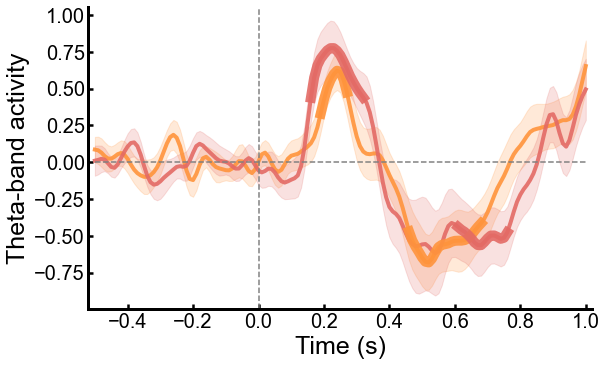

In [107]:
# line_color = ['#E36A65','#5CBBBF']    # 红色湖蓝色 正确快攻击，正确慢攻击 
# line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#E36A65','#FF943C']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
line_color = ['#FF943C', '#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6

# line_color = ['#5CBBBF','#4482CD']    #  正确慢攻击，过快慢攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#4482CD']    #  错误快攻击，过快慢攻击  DE6B48  FFADC6

figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]

# the number of time axis
times = all_sub_moderate_epoch.times

data_1 = np.mean(all_sub_moderate_epoch.get_data(), axis=1)
data_2 = np.mean(all_sub_imminent_epoch.get_data(), axis=1)
plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(data_1, axis=0))
epoch_mean[1] = np.squeeze(np.average(data_2, axis=0))
# plt.plot(times, np.transpose(data_1[-1]))
# plt.legend(subjects)

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')

# 标注哪条线是哪个event
# legend_font = {'family': fontproperties}
# plt.legend(['Moderate', 'Imminent'], fontsize=legend_size, frameon=False)

# # 画每个电极的线：
# tfr_ROI_epoch_fast.ch_names

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
plt.axvline(times[50], c="gray", ls = "dashed")
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

# 画误差(std)
std_event0 = np.squeeze(np.std(data_1, axis=0))
std_event1 = np.squeeze(np.std(data_2, axis=0))

se_event0 = std_event0/np.sqrt(data_1.shape[0])
se_event1 = std_event1/np.sqrt(data_2.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
for i_c, c in enumerate(clusters_fast):
    c = c[0]
    if cluster_p_values_fast[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
for i_c, c in enumerate(clusters_slow):
    c = c[0]
    if cluster_p_values_slow[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# event 间的显著性
for i_c, c in enumerate(clusters):
    c = c[0]
    if cluster_p_values[i_c] <= 0.04:
        
        plt.plot(times[c.start : c.stop - 1], (min_value-0.005) * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)

#hf = plt.plot(times, T_obs, 'g')
#plt.legend((h, ), ('cluster p-value < 0.05', ))
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.02, times[-1]+0.02])
# plt.ylim([-3, 17.5])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("Time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("Theta-band activity", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_new_zlogratio\baseline_insula.jpg',dpi=300, overwrite=True)

# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)

In [71]:
print(cluster_p_values_fast)
print(cluster_p_values_slow)
print(cluster_p_values)

[0.0001 0.0672]
[4.442e-01 1.000e-04 1.918e-01]
[0.0002]


In [ ]:
all_sub_moderate_epoch

In [63]:
cluster_pv

array([1.    , 0.9914, 0.858 , 1.    , 0.9833, 0.9953, 0.9911, 0.519 ,
       0.5121, 0.9996, 1.    ])

In [41]:
decision_time_range  + np.array('3.7343859')

UFuncTypeError: ufunc 'add' did not contain a loop with signature matching types (dtype('<U32'), dtype('<U32')) -> dtype('<U32')

In [24]:
iter_trialtime = decision_time_range + np.array(hebavior_trial['firsttime_stage_3'])[safe_imminent_event_num[iter_trial]]


TypeError: can only concatenate list (not "str") to list

In [12]:
np.array(hebavior_trial['time_stage_3'])[nothreat_event_num[iter_trial]]

'[]'

In [ ]:
# 组水平
from mne.time_frequency import tfr_morlet

freqs=np.arange(4, 31, 1)
# n_cycles = 10
n_cycles=freqs/3
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:
        n_cycles[i] = 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10


time_span = 100
ch_names = []
decision_time_range = [-0.5, 0.5] # decision前后  0.9
baseline_range = [-0.3, 0.1]  # baseline前后 0.3s

# 生成时间序列
time_range = np.arange(baseline_range[0]-baseline_range[1] + decision_time_range[0], decision_time_range[1], 0.001)
for i in range(len(subjects)):

    # 导入eegepoch数据
    ROI_epochs = mne.read_epochs_eeglab(in_path + str(subjects[i]) + '.set')
    # 对错误的event进行矫正
    if subjects[i]==108:
        ROI_epochs.events[61, 2] = 3
    if subjects[i]==119:
        ROI_epochs.events[49, 2] = 1
    if subjects[i]==109:
        ROI_epochs.events[4, 2] = 1
    # 导入event信息数据,分类选择快攻击信息和慢攻击信息
    each_trial_information = pd.read_table(behavior_path + str(subjects[i]) + "each_trial_information.txt", delimiter=" ")
    fast_trial_information = each_trial_information[each_trial_information['trial_condition']==1]
    slow_trial_information = each_trial_information[each_trial_information['trial_condition']==3]
    # 计算tfr
    tfr_ROI_epoch_fast = tfr_morlet(ROI_epochs['1/5/6'], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True)
    tfr_ROI_epoch_slow = tfr_morlet(ROI_epochs['3/5/6'], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True)

    # 截取baseline的信号作为基准  baseline_range
    tfr_ROI_epoch_fast_baseline_data = tfr_ROI_epoch_fast.copy().crop(baseline_range[0], baseline_range[1]-0.001).data
    tfr_ROI_epoch_slow_baseline_data = tfr_ROI_epoch_slow.copy().crop(baseline_range[0], baseline_range[1]-0.001).data

    # 分两个condition进行决策反应前后的截取，后续的对齐，然后进行生成新的mne tfr数据
    for iter_trial in range(tfr_ROI_epoch_fast_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(fast_trial_information['escape_time'])[iter_trial]
        # 利用mne的函数截取数据
        iter_fast_decision_data = tfr_ROI_epoch_fast.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.001).data

        # 存储数据
        if iter_trial == 0: 
            iter_subject_fast_decision_data = iter_fast_decision_data
        else: 
            iter_subject_fast_decision_data = np.vstack((iter_subject_fast_decision_data, iter_fast_decision_data))

    # 慢攻击
    discarded_trial = []
    empty_or_not = 0
    for iter_trial in range(tfr_ROI_epoch_slow_baseline_data.shape[0]):

        # 结合每个trial的数据确定每个trial要截取的时间窗
        iter_trialtime = decision_time_range + np.array(slow_trial_information['escape_time'])[iter_trial]
        if iter_trialtime[1] < 4-0.5: # 时间太长的就不用了
            # 利用mne的函数截取数据
            iter_slow_decision_data = tfr_ROI_epoch_slow.copy()[iter_trial].crop(iter_trialtime[0], iter_trialtime[1]-0.001).data

            # 存储数据
            if empty_or_not == 0: 
                iter_subject_slow_decision_data = iter_slow_decision_data
                empty_or_not = 1
            else: 
                iter_subject_slow_decision_data = np.vstack((iter_subject_slow_decision_data, iter_slow_decision_data))
        else:
            discarded_trial.append(iter_trial)

    # 合并基线段和选择段的数据, slow情况下太长的数据删除
    iter_subject_fast_data = np.concatenate((tfr_ROI_epoch_fast_baseline_data, iter_subject_fast_decision_data), axis=3)
    iter_subject_slow_data = np.concatenate((np.delete(tfr_ROI_epoch_slow_baseline_data, discarded_trial, axis=0), iter_subject_slow_decision_data), axis=3)

    # 生成mne的tfr文件准备进行基线校正
    info = mne.create_info(ch_names = ROI_epochs.ch_names, ch_types = 'eeg', sfreq = 1000)
    # 将所有trial进行平均
    all_fast_mean_data = np.mean(iter_subject_fast_data, axis=0)
    all_slow_mean_data = np.mean(iter_subject_slow_data, axis=0)
    # 生成mne的tfr文件
    all_fast_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_fast_mean_data, times=time_range, freqs=freqs, nave=1)
    all_slow_mean_tfr = mne.time_frequency.AverageTFR(info=info, data=all_slow_mean_data, times=time_range, freqs=freqs, nave=1)

    # 基线校正
    all_fast_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.1, baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.3)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_slow_mean_tfr.apply_baseline(mode='zlogratio', baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.1, baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.3)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # 高斯滤波
    smooth_hgb_fast_data = gaussian_filter(data=all_fast_mean_tfr.data, time_span=time_span, fs=ROI_epochs.info['sfreq'])
    smooth_hgb_slow_data = gaussian_filter(data=all_slow_mean_tfr.data, time_span=time_span, fs=ROI_epochs.info['sfreq'])
    # 得到的数据: trial, channel, time
  
    if i == 0:
        all_smooth_hgb_fast_data = smooth_hgb_fast_data
        all_smooth_hgb_slow_data = smooth_hgb_slow_data
        ch_names = np.array(ROI_epochs.ch_names)
    else:
        all_smooth_hgb_fast_data = np.vstack((all_smooth_hgb_fast_data, smooth_hgb_fast_data))
        all_smooth_hgb_slow_data = np.vstack((all_smooth_hgb_slow_data, smooth_hgb_slow_data))
        ch_names = np.hstack((ch_names, np.array(ROI_epochs.ch_names)))

    print(smooth_hgb_slow_data.shape)